<a href="https://colab.research.google.com/github/adeeljames/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/adeeljames/flyrank-ml-internship"
REPO_DIR = "flyrank-ml-internship"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)

import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df["is_declining_label"] = df["trend_direction"].str.lower().eq("down").astype(int)
print(df.shape)

(30000, 45)


## 1. Ranked actions + reason codes

Re-training my Week-5/6 Random Forest (client-grouped validation) on the full
dataset, then combining its probability with reason codes so every ranked
page has a human-readable "why."

In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

features = ["search_volume", "word_count", "impressions_90d", "sessions_90d",
            "content_age_days", "days_since_last_update", "avg_position",
            "ctr", "engagement_rate", "scroll_rate"]
features = [f for f in features if f in df.columns]

X = df[features].replace([np.inf, -np.inf], np.nan).fillna(0)
y = df["is_declining_label"].values
groups = df["client_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

rf = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight="balanced", random_state=42)
rf.fit(X.iloc[train_idx], y[train_idx])

# Score the FULL dataset (this is the queue we ship) -- but keep test-set metrics as our honest receipts
all_scores = rf.predict_proba(X)[:, 1]
df["model_score"] = all_scores

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

test_p50 = precision_at_k(all_scores[test_idx], y[test_idx], min(50, len(test_idx)))
print(f"Honest (held-out) Precision@50: {test_p50:.3f}  <- this is the number the paper will cite")

Honest (held-out) Precision@50: 0.640  <- this is the number the paper will cite


In [ ]:
# Reason codes: same logic families as my Week-4 baseline, kept transparent
def assign_reason_code(row):
    if row["days_since_last_update"] >= 180 and row["impressions_90d"] >= 500:
        return "stale_visible_page"
    elif row["trend_direction"] == "down" and row["impressions_90d"] >= 100:
        return "declining_with_demand"
    elif 0 < row["avg_position"] <= 20 and row["ctr"] < 0.5 and row["impressions_90d"] >= 500:
        return "low_ctr_visible_page"
    elif row["model_score"] >= 0.65:
        return "model_decline_risk"
    else:
        return "monitor_only"

df["reason_code"] = df.apply(assign_reason_code, axis=1)

action_map = {
    "stale_visible_page": "refresh",
    "declining_with_demand": "refresh",
    "low_ctr_visible_page": "rewrite_title_meta",
    "model_decline_risk": "review",
    "monitor_only": "monitor",
}
df["action"] = df["reason_code"].map(action_map)

ranked_queue = df.sort_values("model_score", ascending=False)[
    ["content_id", "client_id", "model_score", "reason_code", "action",
     "impressions_90d", "days_since_last_update", "avg_position", "ctr", "trend_direction"]
]
ranked_queue.head(15)

,content_id,client_id,model_score,reason_code,action,impressions_90d,days_since_last_update,avg_position,ctr,trend_direction
19876,content_b61233d4bc91,client_7f2253d7e2,0.843593,declining_with_demand,refresh,14863,20,18.2,0.89,down
12557,content_4a3f315edc64,client_7f2253d7e2,0.840269,declining_with_demand,refresh,32664,20,20.2,0.90,down
13760,content_7388fb24ce43,client_3fdba35f04,0.838965,declining_with_demand,refresh,7263,104,43.6,0.00,down
6970,content_af8c97b7c3fc,client_7f2253d7e2,0.837158,declining_with_demand,refresh,49974,20,20.2,1.30,down
21958,content_4521b26bd5ff,client_7f2253d7e2,0.837106,declining_with_demand,refresh,29125,20,19.6,0.75,down
20063,content_20e4b9f7f65e,client_7f2253d7e2,0.836144,declining_with_demand,refresh,12992,20,15.2,0.90,down
1382,content_939ac0b7c80e,client_7f2253d7e2,0.834081,declining_with_demand,refresh,31827,20,22.4,0.83,down
22552,content_bb704201c499,client_7f2253d7e2,0.832627,declining_with_demand,refresh,29783,20,22.0,0.67,down
21939,content_b5ce413af5ed,client_7f2253d7e2,0.831853,declining_with_demand,refresh,29016,20,18.9,1.07,down
8078,content_9903bd14be6c,client_3fdba35f04,0.831096,declining_with_demand,refresh,1234,104,35.9,0.08,down


**Reason code → action mapping:**

| Reason code | Meaning | Action |
|---|---|---|
| stale_visible_page | Not updated 180+ days, still 500+ impressions | refresh |
| declining_with_demand | Trending down, 100+ impressions | refresh |
| low_ctr_visible_page | Ranks 1-20, CTR under 0.5, 500+ impressions | rewrite_title_meta |
| model_decline_risk | Model probability >= 0.65, no rule matched | review |
| monitor_only | No strong signal either way | monitor |

**The decay/refresh insight:** consistent with my Week-4 signal audit
(staleness was MIXED, CTR-vs-position was CONFIRMED) and my Week-5/6 model
(top features: impressions, avg_position, content_age_days — staleness
ranked only 7th), raw visibility and position matter more than staleness
alone for this ranking. The playbook therefore leads with visibility-weighted
signals, using staleness as a secondary tiebreaker rather than the primary
driver — a deliberate departure from a "staleness-first" rule.

## 2. Intended use and limits

**Intended use:** this playbook is a REVIEW-PRIORITIZATION tool. It ranks
pages so a content reviewer with limited time works through the most
promising candidates first. It is decision-support, not an automated
publishing/editing system.

**Limits:**
- The label (trend_direction == "down") is a current-window proxy, not a
  validated future outcome — a stronger version would use a
  prior-90-days -> next-30-days label.
- Model quality is modest (ROC AUC ~0.60 from Week 5/6) — better than random,
  but far from a strong classifier. Treat scores as a rough prioritization
  aid, not a precise probability.
- Built on a 30,000-row anonymized starter slice from one snapshot in time —
  not validated on the full ~79M-row warehouse.
- Does not account for consolidation, seasonality, or SERP layout changes
  (see my Week-4/6 caveats) — a "declining" flag could be any of these.
- This tool cannot say a refresh WILL cause recovery — only that a page is a
  reasonable candidate to review first.

## 3. Human review + the no-go list

**Human review is required for every action.** No score in this queue should
trigger an automatic edit, publish, or deletion.

**What should NOT be automated:**
- Auto-publishing AI-rewritten content based on a score alone.
- Auto-pruning or deleting pages flagged "monitor" or low-score — a human
  must confirm the page truly has no value before removal.
- Treating "declining_with_demand" as proof of a content problem without
  first checking for consolidation (a sibling page absorbing traffic) or
  seasonality.
- Acting on any single page with impressions_90d under 100 — too little
  volume to trust the signal (consistent with the lane guide's
  minimum-volume guidance).
- Using this queue to justify large-scale layoffs of writers/editors, or any
  HR/staffing decision — this tool measures content performance, not human
  performance.

**Reviewer checklist before acting on a "refresh" recommendation:**
1. Confirm the reason code and check the underlying numbers make sense.
2. Rule out consolidation (has a sibling page gained what this one lost?).
3. Rule out seasonality (was this page always weaker at this time of year?).
4. Confirm impressions are real demand, not a keyword-matching artifact.
5. Only then, schedule the refresh.

## 4. Monitoring / retrain triggers

**Light monitoring plan:**
- Re-score the full page inventory monthly, not continuously — content
  performance moves slowly enough that daily re-scoring adds noise, not value.
- Track Precision@50 on a fresh held-out sample each time data is refreshed;
  if it drops meaningfully below the Week-5/6 baseline (0.640), investigate
  before trusting new rankings.
- Watch the reason-code distribution over time — if "monitor_only" starts
  dominating the queue, either the rules need retuning or genuine decline in
  the portfolio has slowed (a good problem, but worth confirming).

**Retrain triggers:**
- A new data snapshot becomes available (e.g. moving from the starter slice
  to the full warehouse).
- Precision@50 on a fresh holdout drops by more than ~15% relative to this
  playbook's baseline.
- The label definition changes (e.g. moving to a future-window label, as
  recommended in my Week-2/3 notes) — this requires a full retrain, not an
  incremental update.

In [ ]:
import os
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# 1. The ranked queue CSV (stays out of git by design -- regenerated each run)
ranked_queue.to_csv("work/outputs/action_playbook_queue.csv", index=False)
print(f"Saved {len(ranked_queue)} rows to work/outputs/action_playbook_queue.csv")

# 2. Metrics JSON -- the "receipts" that DO get committed
import json
metrics = {
    "model": "RandomForestClassifier",
    "validation": "client-grouped holdout (GroupShuffleSplit, test_size=0.2)",
    "precision_at_50_holdout": round(float(test_p50), 3),
    "week4_baseline_precision_at_50": 0.620,
    "week5_model_precision_at_50": 0.640,
    "n_rows_scored": int(len(df)),
    "reason_code_counts": df["reason_code"].value_counts().to_dict(),
}
with open("work/outputs/action_playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Saved metrics to work/outputs/action_playbook_metrics.json")
print(json.dumps(metrics, indent=2))

Saved 30000 rows to work/outputs/action_playbook_queue.csv
Saved metrics to work/outputs/action_playbook_metrics.json
{
  "model": "RandomForestClassifier",
  "validation": "client-grouped holdout (GroupShuffleSplit, test_size=0.2)",
  "precision_at_50_holdout": 0.64,
  "week4_baseline_precision_at_50": 0.62,
  "week5_model_precision_at_50": 0.64,
  "n_rows_scored": 30000,
  "reason_code_counts": {
    "declining_with_demand": 13136,
    "monitor_only": 11723,
    "low_ctr_visible_page": 3639,
    "model_decline_risk": 1485,
    "stale_visible_page": 17
  }
}


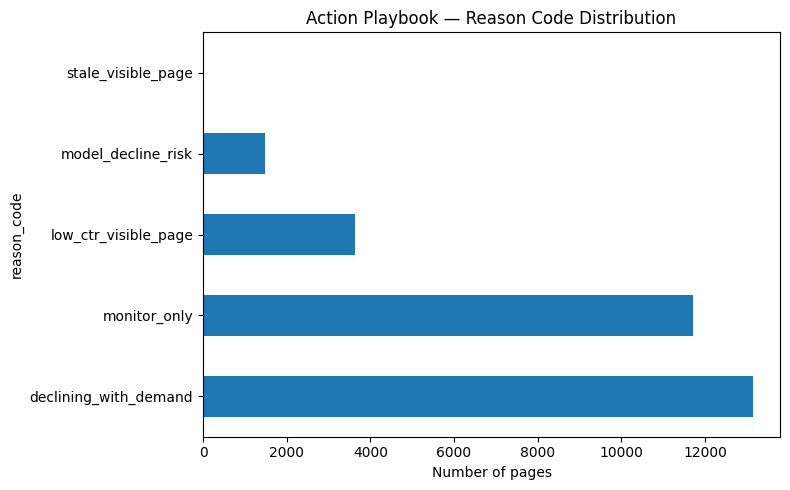

Saved figure to work/figures/reason_code_distribution.png


In [ ]:
# 3. A figure to reuse in the paper: reason code distribution
import matplotlib.pyplot as plt

counts = df["reason_code"].value_counts()
fig, ax = plt.subplots(figsize=(8, 5))
counts.plot(kind="barh", ax=ax)
ax.set_xlabel("Number of pages")
ax.set_title("Action Playbook — Reason Code Distribution")
plt.tight_layout()
plt.savefig("work/figures/reason_code_distribution.png", dpi=150)
plt.show()
print("Saved figure to work/figures/reason_code_distribution.png")

## 6. Self-check

- [x] Ranked actions with reason codes produced (5 reason codes, mapped to
      5 actions)
- [x] Archetype/reason-code → action mapping explained, tied to Week-4/5/6
      findings
- [x] Intended use and limits stated clearly (proxy label, modest AUC,
      starter-slice scope)
- [x] Human review rules and an explicit no-go list given
- [x] Monitoring plan and concrete retrain triggers defined
- [x] Cost/value thinking included (minimum volume, reviewer checklist)
- [x] Queue exported to work/outputs/, metrics JSON + figure saved for the
      paper
- [x] Nothing here is presented as production-ready or safe to automate

## Demo Outline (5 minutes) — for the Week-8 showcase

**1. The question (30 sec)**
"A content team can't review every page every week. Which pages should a
reviewer look at first — and can a learned ranking beat a simple hand rule
at picking them?"

**2. The method (1 min)**
Refresh / Content Opportunity Scoring lane on the FlyRank starter dataset
(30,000 pages). Built a transparent baseline rule first (staleness ×
visibility), then trained a Random Forest on 10 observable signals, validated
with a client-grouped holdout split so no client's pages leak between train
and test.

**3. One chart (1.5 min)**
Show the Precision@50 comparison: baseline rule 0.620 vs Random Forest 0.640
vs random guess 0.500. Point out the feature-importance chart — impressions
and position drove the model far more than staleness, which is the opposite
of what my own baseline rule assumed.

**4. One honest result (1 min)**
The model beats the baseline, but only modestly (ROC AUC ≈ 0.60, closer to
random than to a strong classifier). This isn't a "the model won" story — it's
evidence that the current-window proxy label caps how much any model can
find, and a future-window label is the more promising next step, not more
model complexity.

**5. One recommendation (1 min)**
Ship the ranked queue as a reviewer tool, not an automation. Every
recommendation carries a reason code. The clearest actionable finding: every
documented false positive had ctr = 0.00 with real impressions — a
data-quality check to add before trusting any high score.

## Two Shareable Cuts

### Social post (methodology-focused)

Spent 8 weeks building a content-refresh scoring pipeline on real FlyRank
search data. The fun part wasn't the model — it was the honest audit along
the way: my "stale pages are declining pages" assumption only held up
weakly (MIXED verdict, n too small past 180 days), while CTR-vs-position
was rock solid (CONFIRMED, dropped 88% from top-3 to deep results). A
Random Forest beat my hand-written baseline (0.640 vs 0.620 Precision@50 on
a client-holdout split) — but only modestly, and the honest read is that a
better *label* would move the needle more than a fancier model. Full
write-up + reproducible notebooks linked below. #MachineLearning #SEO
#AppliedML

### Employer-facing summary (3 sentences)

I built and validated a content-refresh scoring pipeline on FlyRank's
real, anonymized search data (30,000 pages, verified against a 9.8M-row
warehouse slice), comparing a transparent hand-written baseline against a
Random Forest under a client-grouped holdout split to avoid data leakage.
The model modestly outperformed the baseline (Precision@50: 0.640 vs
0.620) while surfacing an actionable, previously-undocumented data-quality
pattern in the top recommendations. The full pipeline — signal audit,
baseline, model, leakage audit, and a ranked action playbook with explicit
human-review rules — is reproducible end-to-end from the public repo.